[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FranQuant/llm-regime-allocator/blob/main/notebooks/nb06_live_log.ipynb)

In [1]:
# Setup. On Colab this fetches the repo (data, results, replayable LLM cache); locally it does nothing.
# No API keys or paid calls are needed anywhere in this notebook.
import os, subprocess, sys
if 'google.colab' in sys.modules:
    REPO = '/content/llm-regime-allocator'
    if not os.path.exists(REPO):
        subprocess.run(['git', 'clone', '-q', '--depth', '1', 'https://github.com/FranQuant/llm-regime-allocator.git', REPO], check=True)
    sys.path.insert(0, f'{REPO}/src')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from lra import viz
viz.apply_style()

# nb06 — The live log: forecasts made before the outcome exists

**Question.** Every backtest in nb02–nb05 is on months the models may remember. The only clean test is to forecast months that have not happened yet and wait. This notebook reads the append-only log; it is re-run after each month-end.

## Setup

**Protocol** (`configs/phase10.toml`, committed before the first call). After each month-end, each of the four models gets the blinded snapshot of nb03 and returns regime probabilities. Each row is committed with its model version, response ID and prompt hash; rows are never rewritten.

**Prospective** means the decision date is 2026-10-01 or later *and* the row was logged within 15 days of it. Earlier rows (Jun–Sep 2026) are retrospective: they are after most models' cutoffs but were logged late, so they are shown and never pooled into the test.

**Test.** Per model, prospective rows only: Brier minus uniform with a 3-month block-bootstrap interval. Checkpoints at 12 and 24 scored months; before a checkpoint, nothing is changed because of the scores. Each month is scored once its three-month outcome is published, roughly four months after the call.

In [2]:
M = list(viz.MODEL_COLORS)
logs = {m: viz.read(f'results/live/scores_{m}.csv') for m in M}
FROM = pd.Timestamp('2026-10-01')
for m, l in logs.items():                       # the rule, recomputed rather than trusted from the flag
    lag = pd.to_datetime(l.logged_utc).dt.tz_localize(None) - l.index
    l['prospective'] = (l.index >= FROM) & (lag >= pd.Timedelta(0)) & (lag <= pd.Timedelta(days=15))

## 1. What each model has said so far

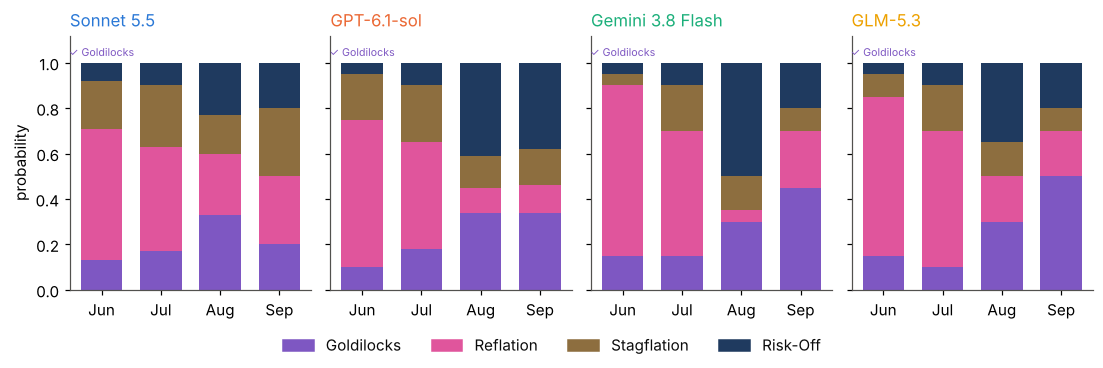

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3.4), sharey=True)
for ax, m in zip(axes, M):
    p = logs[m][viz.REGIMES]; x = np.arange(len(p))
    bottom = np.zeros(len(p))
    for k in viz.REGIMES:
        ax.bar(x, p[k], bottom=bottom, color=viz.REGIME_COLORS[k], width=0.7); bottom += p[k].values
    ax.set_xticks(x, p.index.strftime('%b')); ax.set_title(viz.MODEL_NAMES[m], color=viz.MODEL_COLORS[m])
    ax.grid(False)
    real = logs[m]['realised'].dropna()
    for d, r in real.items():
        i = p.index.get_loc(d); ax.text(i, 1.03, '✓ ' + r.replace('_', '-'), ha='center', fontsize=7,
                                         color=viz.REGIME_COLORS[r])
axes[0].set_ylabel('probability'); axes[0].set_ylim(0, 1.12)
from matplotlib.patches import Patch
fig.legend(handles=[Patch(color=viz.REGIME_COLORS[k], label=k.replace('_', '-')) for k in viz.REGIMES],
           loc='lower center', ncol=4)
fig.subplots_adjust(bottom=0.2, wspace=0.08); plt.show()

**Reading.** All four called Reflation for June 2026; the next quarter turned out Goldilocks (✓), so every model scores worse than uniform on the one month scored so far. In August GPT, Gemini and GLM moved to Risk-Off; by September Gemini and GLM had turned to Goldilocks while GPT stayed Risk-Off, and Sonnet stayed close to uniform throughout. These rows are retrospective; they illustrate the log, they do not count.

## 2. Status

In [4]:
st = pd.DataFrame({viz.MODEL_NAMES[m]: {
    'logged': len(l), 'retrospective': int((~l.prospective).sum()), 'prospective': int(l.prospective.sum()),
    'scored (all)': int(l.brier.notna().sum()), 'scored prospective': int((l.prospective & l.brier.notna()).sum()),
    'model version': ', '.join(l.model_returned.unique())} for m, l in logs.items()}).T
st

,logged,retrospective,prospective,scored (all),scored prospective,model version
Sonnet 5.5,4,4,0,1,0,claude-sonnet-5-5
GPT-6.1-sol,4,4,0,1,0,gpt-6.1-sol
Gemini 3.8 Flash,4,4,0,1,0,gemini-3.8-flash
GLM-5.3,4,4,0,1,0,glm-5.3


**Reading.** **Key finding:** no prospective month exists yet. The first is the October 2026 month-end, logged in early November and scored around February 2027; the first checkpoint (12 scored months) falls in early 2028. No model version has changed since the log began.

## What we can and cannot claim

- **Nothing yet.** One retrospective month is scored, and every model missed it.
- **The design is fixed in advance:** models, prompt, rules and analysis were committed before the first call, and a declared correction (Sep-2026 rows mis-flagged as prospective) was made before any of their outcomes existed.
- **Power is low.** At the backtest edges, a decisive answer needs roughly four to five years for Sonnet and longer for the others. The checkpoints are progress reports, not verdicts.

## Next

Re-run after each month-end: `build_macro.py` → `check_live_prices.py` → `run_live.py` → `score_live.py`, then commit and tag `live-YYYY-MM`.